<a href="https://colab.research.google.com/github/marcuslee6/Insurance-Analytics-Scheme/blob/main/survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

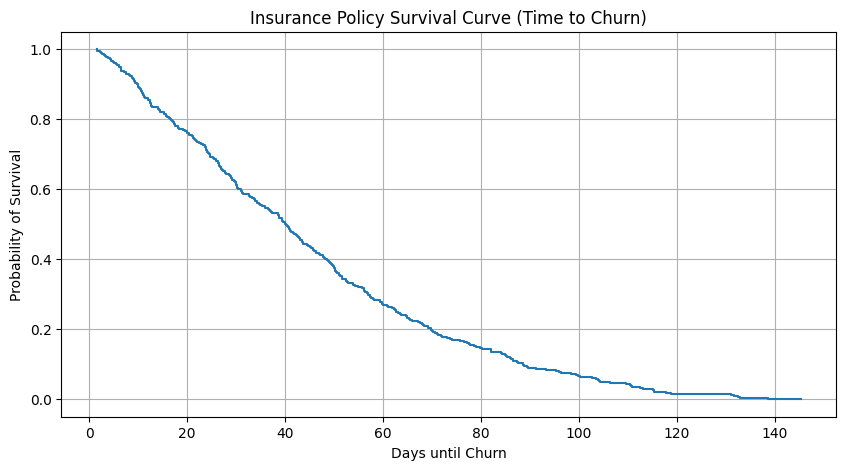

Chi-Squared Test (Goodness of Fit) P-value: 0.0000
White Noise Model - AIC: 762.55, BIC: 767.76
Random Walk Model - AIC: 972.00, BIC: 977.21


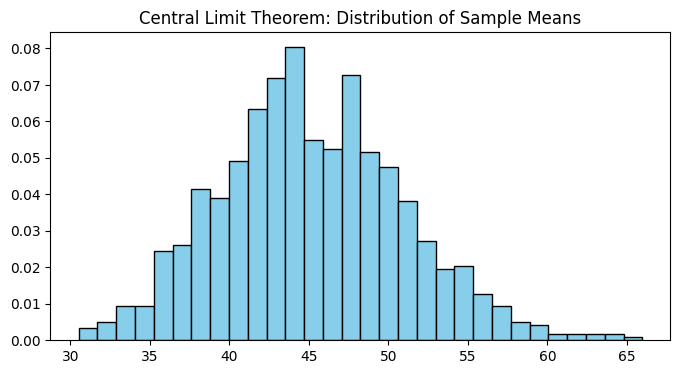

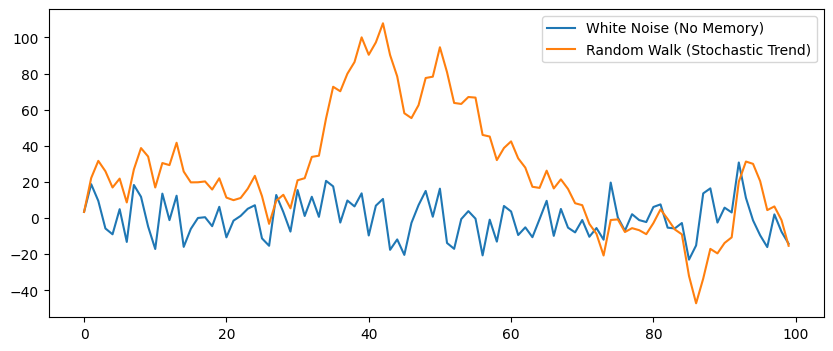

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

# 1. DATA SIMULATION (Survival & Time Series Logic)
np.random.seed(42)
n_policies = 500

# Survival Logic: Time until churn (Weibull Distribution)
# Hazard Rate increases over time if shape > 1
durations = stats.weibull_min.rvs(c=1.5, scale=50, size=n_policies)
event_observed = np.ones(n_policies) # Assume all have churned for simplicity

# Time Series Logic: Daily Claims (Random Walk vs White Noise)
n_days = 100
white_noise = np.random.normal(0, 10, n_days)
random_walk = np.cumsum(white_noise) # S_t = S_{t-1} + epsilon

# 2. SURVIVAL FUNCTION & HAZARD RATE (Kaplan-Meier Logic)
# Sorting for survival curve plotting
sorted_durations = np.sort(durations)
survival_prob = 1.0 - (np.arange(1, n_policies + 1) / n_policies)

plt.figure(figsize=(10, 5))
plt.step(sorted_durations, survival_prob, label='Survival Function S(t)')
plt.title('Insurance Policy Survival Curve (Time to Churn)')
plt.xlabel('Days until Churn')
plt.ylabel('Probability of Survival')
plt.grid(True)
plt.show()

# 3. GOODNESS OF FIT & CHI-SQUARED TEST
# Test if our churn data fits a Normal Distribution (spoiler: it won't)
observed_counts, bin_edges = np.histogram(durations, bins=10)
# Expected counts under Normal Distribution
mu, std = np.mean(durations), np.std(durations)
expected_probs = stats.norm.cdf(bin_edges[1:], mu, std) - stats.norm.cdf(bin_edges[:-1], mu, std)
expected_counts = expected_probs * n_policies

# 3.1. Normalize probabilities so they sum to 1
expected_probs = expected_probs / np.sum(expected_probs)

# 3.2. Calculate expected counts based on normalized probabilities
expected_counts = expected_probs * n_policies

# 3.3Now the sum of expected_counts will match n_policies exactly
chi_sq_stat, p_val = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
print(f"Chi-Squared Test (Goodness of Fit) P-value: {p_val:.4f}")

# 4. MODEL SELECTION: AIC & BIC
# Comparing two simple linear models for Claims
X = sm.add_constant(np.arange(n_days))
model_wn = sm.OLS(white_noise, X).fit()
model_rw = sm.OLS(random_walk, X).fit()

print(f"White Noise Model - AIC: {model_wn.aic:.2f}, BIC: {model_wn.bic:.2f}")
print(f"Random Walk Model - AIC: {model_rw.aic:.2f}, BIC: {model_rw.bic:.2f}")

# 5. CENTRAL LIMIT THEOREM (CLT) DEMO
# Showing that the mean of claims tends toward Normal Distribution
means = [np.mean(np.random.choice(durations, 30)) for _ in range(1000)]
plt.figure(figsize=(8, 4))
plt.hist(means, bins=30, density=True, color='skyblue', edgecolor='black')
plt.title('Central Limit Theorem: Distribution of Sample Means')
plt.show()

# 6. RANDOM WALK vs WHITE NOISE DIAGNOSTICS
plt.figure(figsize=(10, 4))
plt.plot(white_noise, label='White Noise (No Memory)')
plt.plot(random_walk, label='Random Walk (Stochastic Trend)')
plt.legend()
plt.show()
